# Batch Independent GPQR (Center-Gap)

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.means import ConstantMean, Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.centergap import CenterGapMean
from gpytorch_qr.gpqr_cg import (
    BatchCenterGapQuantileGP,
    BatchCenterGapQuantileGPLikelihood,
)

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 10000))

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

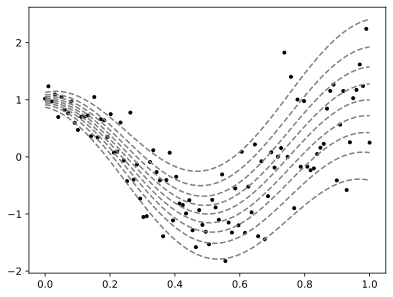

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Prior mean

In [ ]:
class CenterMean(Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])


prior_mean = CenterMean().to(device)

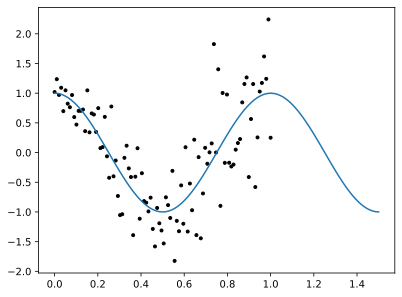

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), prior_mean(x_pred).detach().cpu())
plt.show()

## Define models and likelihoods

In [ ]:
class MyGP_PriorMean(BatchCenterGapQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_lower_quantiles):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_quantiles]),
        )
        variational_strategy = UnwhitenedVariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        mean = CenterGapMean(
            CenterMean(batch_shape=torch.Size([1])),
            ConstantMean(batch_shape=torch.Size([num_quantiles - 1])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_quantiles])),
            batch_shape=torch.Size([num_quantiles]),
        )
        super().__init__(variational_strategy, mean, covar, num_lower_quantiles)


inducing_points = x.detach().clone()
central_q_index = (q - 0.5).abs().argmin().item()
gp_priormean = MyGP_PriorMean(inducing_points, len(q), central_q_index).to(device)
likelihood_priormean = BatchCenterGapQuantileGPLikelihood(q, central_q_index).to(device)

## Train

In [ ]:
gp_priormean.train()
likelihood_priormean.train()
mll = VariationalELBO(likelihood_priormean, gp_priormean, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_priormean.parameters()) + list(likelihood_priormean.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp_priormean(x)
    loss = -mll(output, y).sum()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

/home/jisoosong/miniconda3/envs/heavyedge/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


/home/jisoosong/miniconda3/envs/heavyedge/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


/home/jisoosong/miniconda3/envs/heavyedge/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagonal
  warnings.warn(


## Evaluate

In [ ]:
gp_priormean.eval()
with torch.no_grad():
    quantiles_priormean = gp_priormean.mean_quantiles_mc(x_pred)

## Plot result

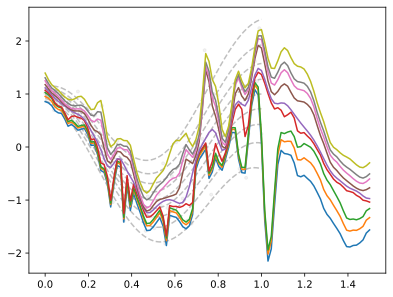

In [ ]:
colors = plt.cm.tab10(range(len(q)))

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray", alpha=0.5)

for i in range(len(q)):
    plt.plot(x_pred.cpu(), quantiles_priormean[i].cpu(), color=colors[i])

plt.show()